In [3]:
%pip install numpy
%pip install missingno matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


,_id,created_at,updated_at,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type
count,84633.000000,84633,84633,8.463300e+04,8.463300e+04,84633.000000,8.463300e+04,9871.000000,84633.000000,84481,84633
unique,NaN,84633,84633,NaN,NaN,NaN,NaN,NaN,NaN,1388,53
top,NaN,2020-10-18T13:26:17.365Z,2020-10-18T13:26:17.365Z,NaN,NaN,NaN,NaN,NaN,NaN,Quốc lộ 1,tertiary
freq,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,2142,36390
mean,42316.000000,NaN,NaN,3.674041e+09,3.672725e+09,41.818050,2.866904e+08,54.503596,3.500006,NaN,NaN
std,24431.587003,NaN,NaN,2.039756e+09,2.040056e+09,52.692336,2.085526e+08,16.553367,0.841222,NaN,NaN
min,0.000000,NaN,NaN,3.663672e+08,3.663672e+08,0.000000,3.109679e+07,10.000000,1.000000,NaN,NaN
25%,21158.000000,NaN,NaN,2.078951e+09,2.078951e+09,13.000000,3.511357e+07,40.000000,3.000000,NaN,NaN
50%,42316.000000,NaN,NaN,4.068031e+09,4.068031e+09,27.000000,2.517313e+08,60.000000,4.000000,NaN,NaN
75%,63474.000000,NaN,NaN,5.748273e+09,5.748270e+09,52.000000,4.693276e+08,60.000000,4.000000,NaN,NaN


<Figure size 1000x600 with 0 Axes>

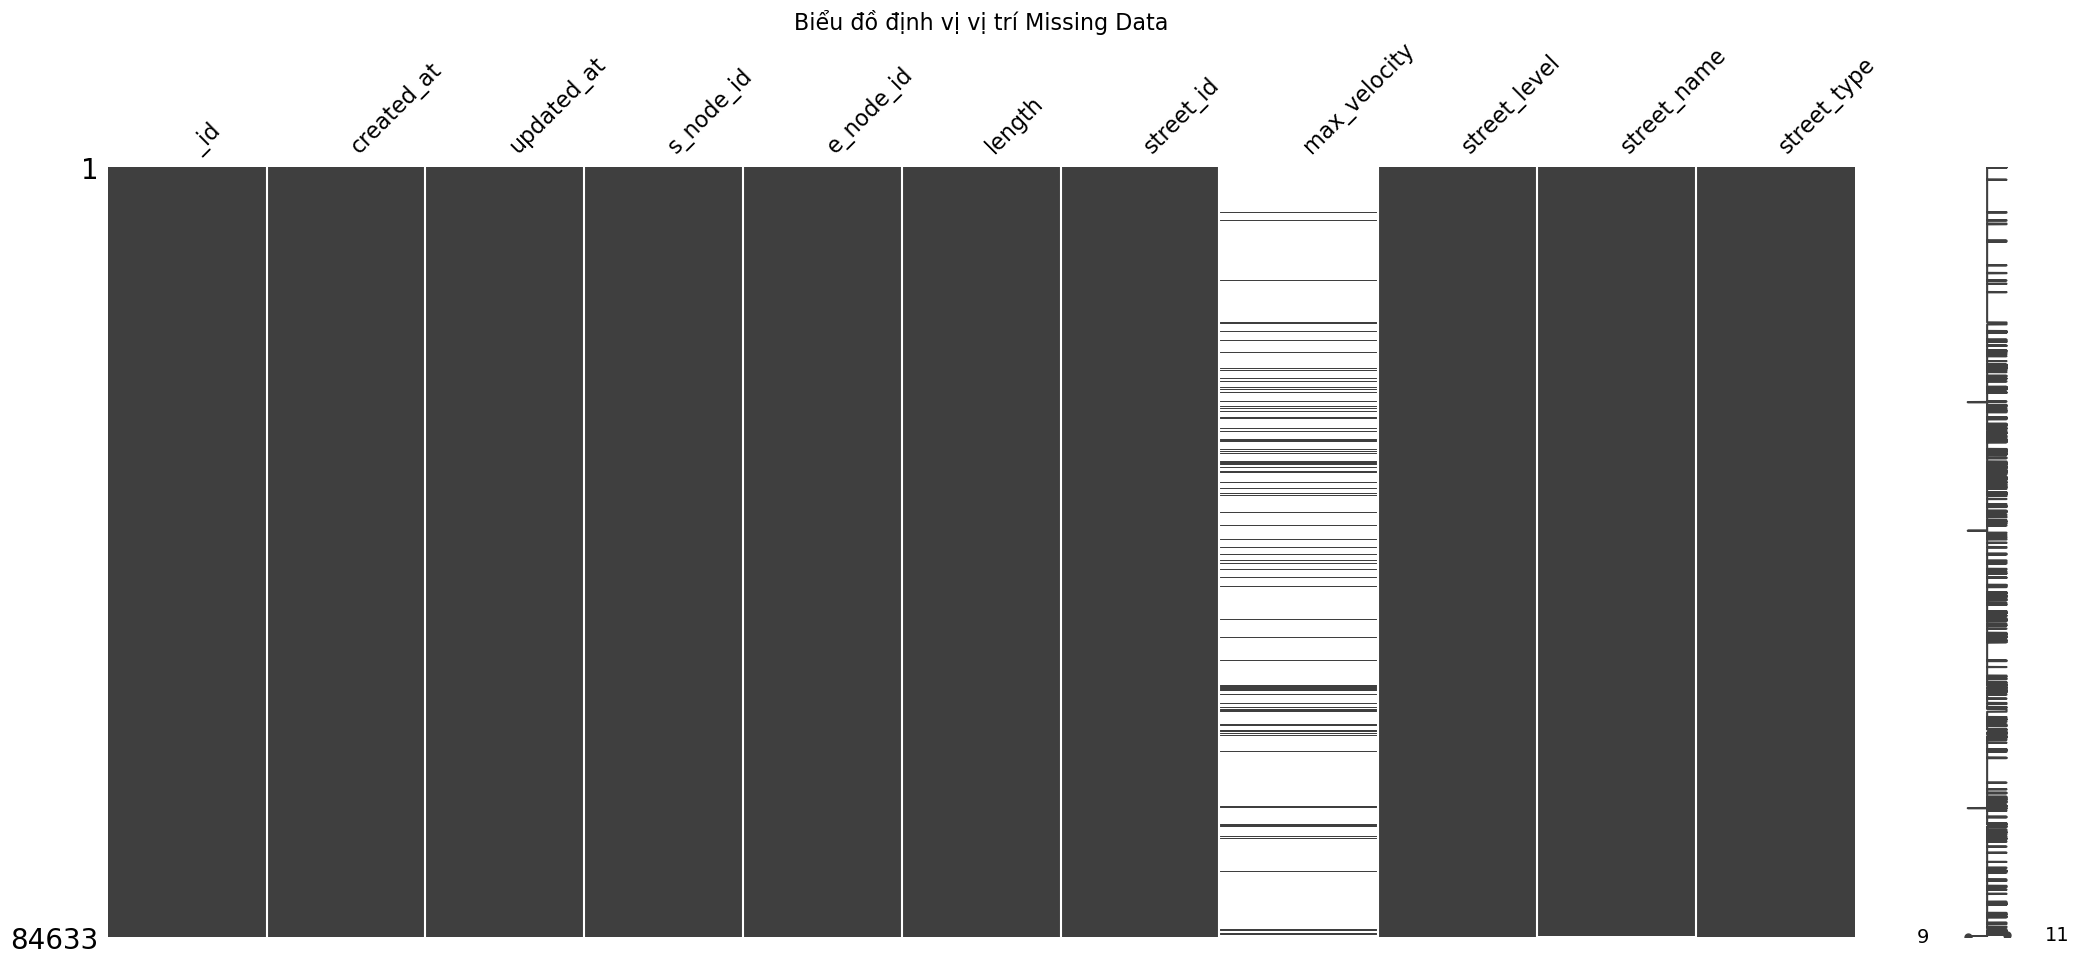

In [4]:
# pre-processing data
# file street.csv is missing max_velocity field with 82%
# segments.csv is missing max_velocity field with 88%
# we will refined the dataset by auto-fill value to missing element
# mapping of velocity for each street level:
# 1: 60.0
# 2: 50.0
# 3: 40.0
# 4: 30.0
# 5: 30.0

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# create velocity map
level_velocity_map = {1: 60.0, 2: 50.0, 3: 40.0, 4: 30.0, 5: 30.0}

# read file
#data_street = pd.read_csv("data/streets.csv")
data_street = pd.read_csv("data/segments.csv")
display(data_street.describe(include='all'))

# show missing values
plt.figure(figsize=(10, 6))
msno.matrix(data_street)
plt.title("Biểu đồ định vị vị trí Missing Data", fontsize=16)
plt.show()


In [6]:
import os
def impute_velocity(row):
    if pd.isna(row["max_velocity"]) or row["max_velocity"] <= 0:
        level = row["street_level"]
        max_velo_allowed = level_velocity_map.get(level, 40.0)
        return max_velo_allowed
    return row["max_velocity"]

data_street["max_velocity"] = data_street.apply(impute_velocity, axis=1)

os.makedirs("refined", exist_ok=True)

output_path = "refined/segments_refined.csv"
data_street.to_csv(output_path, index=False, encoding="utf-8-sig")

print("\n--- Thong ke sau khi xu ly ---")
display(data_street.describe(include='all'))

print(f"\nĐã xuất dữ liệu sạch thành công ra file: {output_path}")
print(f"Tổng số dòng hiện tại: {len(data_street)}")


--- Thong ke sau khi xu ly ---


,_id,created_at,updated_at,s_node_id,e_node_id,length,street_id,max_velocity,street_level,street_name,street_type
count,84633.000000,84633,84633,8.463300e+04,8.463300e+04,84633.000000,8.463300e+04,84633.000000,84633.000000,84481,84633
unique,NaN,84633,84633,NaN,NaN,NaN,NaN,NaN,NaN,1388,53
top,NaN,2020-10-18T13:26:17.365Z,2020-10-18T13:26:17.365Z,NaN,NaN,NaN,NaN,NaN,NaN,Quốc lộ 1,tertiary
freq,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,2142,36390
mean,42316.000000,NaN,NaN,3.674041e+09,3.672725e+09,41.818050,2.866904e+08,35.936160,3.500006,NaN,NaN
std,24431.587003,NaN,NaN,2.039756e+09,2.040056e+09,52.692336,2.085526e+08,10.776316,0.841222,NaN,NaN
min,0.000000,NaN,NaN,3.663672e+08,3.663672e+08,0.000000,3.109679e+07,10.000000,1.000000,NaN,NaN
25%,21158.000000,NaN,NaN,2.078951e+09,2.078951e+09,13.000000,3.511357e+07,30.000000,3.000000,NaN,NaN
50%,42316.000000,NaN,NaN,4.068031e+09,4.068031e+09,27.000000,2.517313e+08,30.000000,4.000000,NaN,NaN
75%,63474.000000,NaN,NaN,5.748273e+09,5.748270e+09,52.000000,4.693276e+08,40.000000,4.000000,NaN,NaN



Đã xuất dữ liệu sạch thành công ra file: refined/segments_refined.csv
Tổng số dòng hiện tại: 84633
